# Imports

In [18]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Define country and parameters

In [19]:
# Select target country
country = 'Argentina'

# Set country-specific parameters: ISO codes and buffer size (in meters)
if country == 'Argentina':
    country_short = 'ARG'   # ISO 3-letter code
    country_code = 'AR'     # ISO 2-letter code
elif country == 'Chile':
    country_short = 'CHL'
    country_code = 'CL'
elif country == 'Colombia':
    country_short = 'COL'
    country_code = 'CO'
# Uncomment the following if Mexico is to be included in the analysis
# elif country == 'Mexico':
#     country_short = 'MEX'
#     country_code = 'MX'

# Set working directory

In [20]:
# Define working directory path
wd = (
    '/your/path/to/working/directory/'
)

# Load baseline data
Two options:<br>
    - with raw data (reported) only<br>
    - with both raw and estimated data from imputed baseline when raw data is missing <br>

In [21]:
# Set to True or False according to desired option (see description above)
raw = False

# Set to a string like 'subunit0' for conservative-imputed movement inputs.
# Set to a string like 'standard' for non - conservative-imputed movement inputs.
# Set to a string like 'censored10' for imputed movement inputs below 10.
imputed_version = 'censored10'
imputed_input_suffix = f'-{imputed_version}' if imputed_version else ''
imputed_output_tag = imputed_version


In [22]:
# Load baseline movement data depending on the flag
if raw == True:
    baseline_mov = pd.read_csv(
        os.path.join(wd, 'data', 'outputs', country_short, 'baseline', 'baseline_mov.csv')
    )
else:
    baseline_mov_imput = pd.read_csv(
        os.path.join(
            wd, 'data', 'outputs', country_short,
            'baseline', f'movcell-baseline-imput-mov-dist-with-exo-var-flatten{imputed_input_suffix}.csv'
        )
    ).drop(columns='Unnamed: 0', errors='ignore')

# Load imputed baseline population data with exogenous variables
baseline_pop_imput = gpd.read_file(
    os.path.join(
        wd, 'data', 'outputs', country_short,
        'grids-with-data', 'movcell-baseline-imput-pop-with-exo-var',
        'movcell-baseline-imput-pop-with-exo-var.gpkg'
    )
)


# Evolution by day distance > 0

In [23]:
# Define the directory containing daily movement data
directory = os.path.join(wd, 'data', 'outputs', country_short, 'mov')

# Get a sorted list of non-hidden files in the movement data directory
files = sorted([file for file in os.listdir(directory) if not file.startswith('.')])

# Extract start and end dates from filenames (assuming format includes YYYY-MM-DD near the end)
start_date = datetime.strptime(files[0][-19:-9], '%Y-%m-%d')
end_date = datetime.strptime(files[-1][-19:-9], '%Y-%m-%d')

# Compute the number of days in the movement data time span
delta = end_date - start_date

# Generate list of column names as date strings for each day in the time range
columns = [str(start_date + timedelta(days=i))[:10] for i in range(delta.days + 1)]

# Initialise empty DataFrame for movement data evolution based on `raw` flag
if raw == True:
    # Create DataFrame with NaNs and same number of rows as baseline raw data
    df_mov_evo_dist = pd.DataFrame({
        column: [np.nan] * len(baseline_mov) for column in columns
    })

    # Insert origin and destination columns from raw baseline data
    df_mov_evo_dist.insert(0, 'D', baseline_mov['D'])
    df_mov_evo_dist.insert(0, 'O', baseline_mov['O'])

    # Create a copy to represent baseline movement for comparison or extension
    df_mov_evo_dist_baseline_from_mov = df_mov_evo_dist.copy()

else:
    # Create DataFrame with NaNs and same number of rows as imputed baseline data
    df_mov_evo_dist = pd.DataFrame({
        column: [np.nan] * len(baseline_mov_imput) for column in columns
    })

    # Insert origin and destination columns from imputed baseline data
    df_mov_evo_dist.insert(0, 'D', baseline_mov_imput['D'])
    df_mov_evo_dist.insert(0, 'O', baseline_mov_imput['O'])

    # Create a copy for later reference or baseline comparison
    df_mov_evo_dist_baseline_from_baseline = df_mov_evo_dist.copy()


In [25]:
imputed_output_tag

'censored10'

In [26]:
# NOTE: This block is slow to run. Only run if you want to regenerate movement evolution files.

for i in range(len(files)):
    # Print progress every 50 files
    if i % 50 == 0:
        print(f"Processing {i / len(files) * 100:.2f}%")

    file = files[i]
    file_path = os.path.join(directory, file)

    # Load movement file and drop unnecessary column
    df_movs = pd.read_csv(file_path).drop('Unnamed: 0', axis=1)

    # Extract date and weekday from filename
    date_str = file[-19:-9]
    wday = datetime.strptime(date_str, "%Y-%m-%d").weekday()

    for j in range(len(df_movs)):
        if df_movs.loc[j, 'length_km'] > 0:
            start_FID = df_movs.loc[j, 'start_FID']
            end_FID = df_movs.loc[j, 'end_FID']

            try:
                # Filter for matching Origin-Destination pair
                df_od = df_mov_evo_dist[
                    (df_mov_evo_dist['O'] == start_FID) &
                    (df_mov_evo_dist['D'] == end_FID)
                ]

                index = df_od.index[0]

                # Get crisis and baseline values
                n_crisis = df_movs.loc[j, 'n_crisis']
                n_baseline = baseline_mov_imput.loc[index, str(wday)]

                if pd.notna(n_crisis) and pd.notna(n_baseline):
                    df_mov_evo_dist.loc[index, date_str] = n_crisis

                    if raw:
                        df_mov_evo_dist_baseline_from_mov.loc[index, date_str] = n_baseline
                else:
                    # If raw is False and we have percent change instead of absolute values
                    if not raw:
                        percent_change = df_movs.loc[j, 'percent_change']
                        df_mov_evo_dist.loc[index, date_str] = (
                            n_baseline * percent_change / 100 + n_baseline
                        )

                if not raw:
                    df_mov_evo_dist_baseline_from_baseline.loc[index, date_str] = n_baseline

            except Exception:
                print('OD pair not found')

# Save results to appropriate files based on raw flag
output_dir = os.path.join(wd, 'data', 'outputs', country_short, 'evo')

if raw == True:
    df_mov_evo_dist.to_csv(os.path.join(output_dir, 'mov_evo_dist_raw.csv'), index=False)
    df_mov_evo_dist_baseline_from_mov.to_csv(os.path.join(output_dir, 'mov_evo_baseline_dist_raw.csv'), index=False)
else:
    df_mov_evo_dist.to_csv(os.path.join(output_dir, f'mov_evo_dist_{imputed_output_tag}.csv'), index=False)
    df_mov_evo_dist_baseline_from_baseline.to_csv(os.path.join(output_dir, f'mov_evo_baseline_dist_{imputed_output_tag}.csv'), index=False)


Processing 0.00%
Processing 6.59%
Processing 13.18%
Processing 19.76%
Processing 26.35%
Processing 32.94%
Processing 39.53%
Processing 46.11%
Processing 52.70%
Processing 59.29%
Processing 65.88%
Processing 72.46%
Processing 79.05%
Processing 85.64%
Processing 92.23%
Processing 98.81%


# Load crisis data generated above for further adjustments

In [27]:
df_pop_evo = pd.read_csv(
    f"{wd}/data/outputs/{country_short}/evo/pop_evo_movcell.csv"
).drop("Unnamed: 0", axis=1)

if raw == True:
    df_mov_evo = pd.read_csv(
        f"{wd}/data/outputs/{country_short}/evo/mov_evo_dist_raw.csv"
    ).drop("Unnamed: 0", axis=1)

    df_mov_evo_baseline = pd.read_csv(
        f"{wd}/data/outputs/{country_short}/evo/mov_evo_baseline_dist_raw.csv"
    ).drop("Unnamed: 0", axis=1)
else:
    df_mov_evo = pd.read_csv(
        f"{wd}/data/outputs/{country_short}/evo/mov_evo_dist_{imputed_output_tag}.csv"
    )

    df_mov_evo_baseline = pd.read_csv(
        f"{wd}/data/outputs/{country_short}/evo/mov_evo_baseline_dist_{imputed_output_tag}.csv"
    )

column_to_drop = [
    column for column in df_pop_evo.columns[1:]
    if column not in df_mov_evo.columns[2:]
]
df_pop_evo = df_pop_evo.drop(column_to_drop, axis=1)

column_to_drop = [
    column for column in df_mov_evo.columns[2:]
    if column not in df_pop_evo.columns[1:]
]
df_mov_evo = df_mov_evo.drop(column_to_drop, axis=1)


# Example of evolution of movements and movements/FBuser

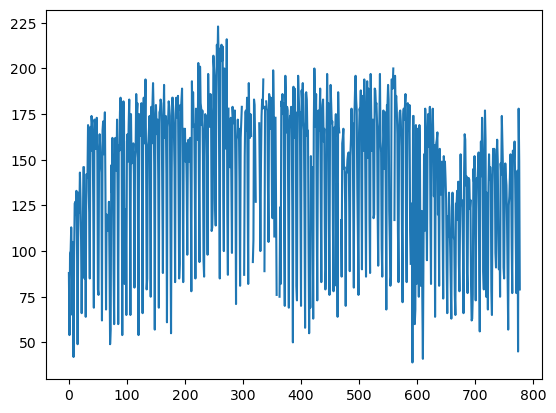

In [28]:
row = 1750
origin = df_mov_evo.loc[row, "O"]

evo_movs = df_mov_evo.loc[row, df_mov_evo.columns[2:]]
plt.plot(np.arange(len(evo_movs)), evo_movs)
plt.show()

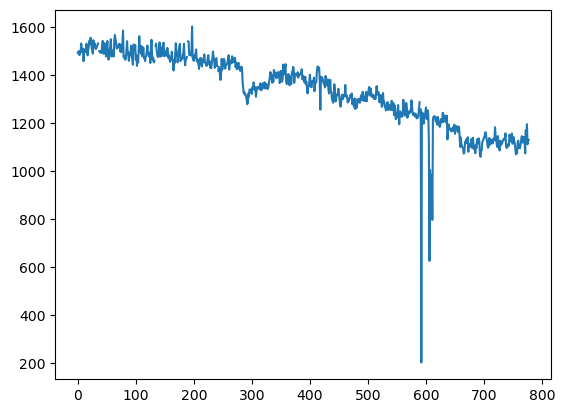

In [29]:
evo_pops = df_pop_evo[df_pop_evo["FID"] == origin].reset_index(drop=True)
evo_pops = evo_pops.loc[0, evo_pops.columns[1:]]
plt.plot(np.arange(len(evo_pops)), evo_pops)
plt.show()

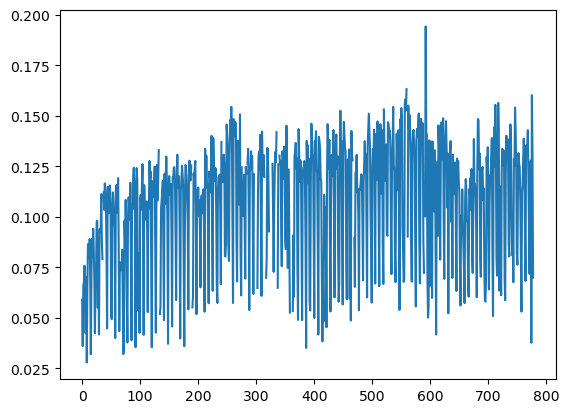

In [30]:
evo_movs_per_pop = [
    evo_movs[i] / evo_pops[i] if pd.notna(evo_pops[i]) else np.nan
    for i in range(len(evo_pops))
]

fig, ax = plt.subplots()
ax.plot(np.arange(len(evo_movs_per_pop)), evo_movs_per_pop)
plt.show()

# Adjust FB movs with quotient of median (baseline) and daily pop in tile

In [31]:
df_mov_evo_adjust = df_mov_evo.copy()

# Drop movement columns not found in population evolution
for column in df_mov_evo_adjust.columns[2:]:
    if column not in df_pop_evo.columns:
        df_mov_evo_adjust = df_mov_evo_adjust.drop(column, axis=1)

index_to_drop = []

# Compute median total population across all time points
median = np.median([
    np.sum(df_pop_evo[column])
    for column in df_pop_evo.columns[1:]
])

for i in range(len(df_mov_evo_adjust)):
    if i % 1000 == 0:
        print(i / len(df_mov_evo_adjust) * 100)

    origin = df_mov_evo_adjust.loc[i, "O"]

    if origin in baseline_pop_imput.index:
        for column in df_mov_evo_adjust.columns[2:]:
            if pd.notna(df_mov_evo_adjust.loc[i, column]):
                if pd.notna(median) and pd.notna(df_pop_evo.loc[origin, column]):
                    df_mov_evo_adjust.loc[i, column] = (
                        df_mov_evo_adjust.loc[i, column] * median / np.sum(df_pop_evo[column])
                    )
                else:
                    df_mov_evo_adjust.loc[i, column] = np.nan
    else:
        index_to_drop.append(i)

df_mov_evo_adjust = df_mov_evo_adjust.drop(index_to_drop).reset_index(drop=True)

df_mov_evo_adjust.to_csv(
    f"{wd}/data/outputs/{country_short}/evo/mov_evo_dist_adjust_{imputed_output_tag}.csv"
)


0.0
1.570598397989634
3.141196795979268
4.711795193968902
6.282393591958536
7.85299198994817
9.423590387937804
10.994188785927438
12.564787183917073
14.135385581906707
15.70598397989634
17.276582377885973
18.847180775875607
20.41777917386524
21.988377571854876
23.55897596984451
25.129574367834145
26.700172765823776
28.270771163813414
29.84136956180305
31.41196795979268
32.98256635778232
34.553164755771945
36.12376315376159
37.694361551751214
39.26495994974085
40.83555834773048
42.40615674572012
43.97675514370975
45.54735354169939
47.11795193968902
48.688550337678656
50.25914873566829
51.829747133657925
53.40034553164755
54.970943929637194
56.54154232762683
58.112140725616456
59.6827391236061
61.25333752159573
62.82393591958536
64.394534317575
65.96513271556464
67.53573111355426
69.10632951154389
70.67692790953353
72.24752630752317
73.8181247055128
75.38872310350243
76.95932150149207
78.5299198994817
80.10051829747134
81.67111669546097
83.24171509345061
84.81231349144024
86.382911889429

In [32]:
df_mov_evo_adjust = df_mov_evo.copy()

# Drop movement columns that are not present in population evolution
for column in df_mov_evo_adjust.columns[2:]:
    if column not in df_pop_evo.columns:
        df_mov_evo_adjust.drop(column, axis=1, inplace=True)

index_to_drop = []

# Compute median total population over all dates
median = np.median([
    df_pop_evo[column].sum()
    for column in df_pop_evo.columns[1:]
])

for i in range(len(df_mov_evo_adjust)):
    if i % 1000 == 0:
        print(i / len(df_mov_evo_adjust) * 100)

    origin = df_mov_evo_adjust.loc[i, "O"]

    if origin in baseline_pop_imput.index:
        for column in df_mov_evo_adjust.columns[2:]:
            value = df_mov_evo_adjust.loc[i, column]
            pop_value = df_pop_evo.loc[origin, column] if column in df_pop_evo.columns else np.nan

            if pd.notna(value) and pd.notna(median) and pd.notna(pop_value):
                adjusted_value = value * median / df_pop_evo[column].sum()
                df_mov_evo_adjust.loc[i, column] = adjusted_value
            else:
                df_mov_evo_adjust.loc[i, column] = np.nan
    else:
        index_to_drop.append(i)

df_mov_evo_adjust.drop(index_to_drop, inplace=True)
df_mov_evo_adjust.reset_index(drop=True, inplace=True)

output_path = f"{wd}/data/outputs/{country_short}/evo/mov_evo_dist_adjust_{imputed_output_tag}.csv"
df_mov_evo_adjust.to_csv(output_path)


0.0
1.570598397989634
3.141196795979268
4.711795193968902
6.282393591958536
7.85299198994817
9.423590387937804
10.994188785927438
12.564787183917073
14.135385581906707
15.70598397989634
17.276582377885973
18.847180775875607
20.41777917386524
21.988377571854876
23.55897596984451
25.129574367834145
26.700172765823776
28.270771163813414
29.84136956180305
31.41196795979268
32.98256635778232
34.553164755771945
36.12376315376159
37.694361551751214
39.26495994974085
40.83555834773048
42.40615674572012
43.97675514370975
45.54735354169939
47.11795193968902
48.688550337678656
50.25914873566829
51.829747133657925
53.40034553164755
54.970943929637194
56.54154232762683
58.112140725616456
59.6827391236061
61.25333752159573
62.82393591958536
64.394534317575
65.96513271556464
67.53573111355426
69.10632951154389
70.67692790953353
72.24752630752317
73.8181247055128
75.38872310350243
76.95932150149207
78.5299198994817
80.10051829747134
81.67111669546097
83.24171509345061
84.81231349144024
86.382911889429

# Adjust FB movs evo baseline

In [33]:
df_mov_evo_adjust = df_mov_evo.copy()

# Drop movement columns that are not present in population evolution
for column in df_mov_evo_adjust.columns[2:]:
    if column not in df_pop_evo.columns:
        df_mov_evo_adjust.drop(column, axis=1, inplace=True)

index_to_drop = []

# Compute median total population over all dates
median = np.median([
    df_pop_evo[column].sum()
    for column in df_pop_evo.columns[1:]
])

for i in range(len(df_mov_evo_adjust)):
    if i % 1000 == 0:
        print(i / len(df_mov_evo_adjust) * 100)

    origin = df_mov_evo_adjust.loc[i, "O"]

    if origin in baseline_pop_imput.index:
        for column in df_mov_evo_adjust.columns[2:]:
            value = df_mov_evo_adjust.loc[i, column]
            pop_value = df_pop_evo.loc[origin, column] if column in df_pop_evo.columns else np.nan

            if pd.notna(value) and pd.notna(median) and pd.notna(pop_value):
                adjusted_value = value * median / df_pop_evo[column].sum()
                df_mov_evo_adjust.loc[i, column] = adjusted_value
            else:
                df_mov_evo_adjust.loc[i, column] = np.nan
    else:
        index_to_drop.append(i)

df_mov_evo_adjust.drop(index_to_drop, inplace=True)
df_mov_evo_adjust.reset_index(drop=True, inplace=True)

output_path = f"{wd}/data/outputs/{country_short}/evo/mov_evo_dist_adjust_{imputed_output_tag}.csv"
df_mov_evo_adjust.to_csv(output_path)
  


0.0
1.570598397989634
3.141196795979268
4.711795193968902
6.282393591958536
7.85299198994817
9.423590387937804
10.994188785927438
12.564787183917073
14.135385581906707
15.70598397989634
17.276582377885973
18.847180775875607
20.41777917386524
21.988377571854876
23.55897596984451
25.129574367834145
26.700172765823776
28.270771163813414
29.84136956180305
31.41196795979268
32.98256635778232
34.553164755771945
36.12376315376159
37.694361551751214
39.26495994974085
40.83555834773048
42.40615674572012
43.97675514370975
45.54735354169939
47.11795193968902
48.688550337678656
50.25914873566829
51.829747133657925
53.40034553164755
54.970943929637194
56.54154232762683
58.112140725616456
59.6827391236061
61.25333752159573
62.82393591958536
64.394534317575
65.96513271556464
67.53573111355426
69.10632951154389
70.67692790953353
72.24752630752317
73.8181247055128
75.38872310350243
76.95932150149207
78.5299198994817
80.10051829747134
81.67111669546097
83.24171509345061
84.81231349144024
86.382911889429